# Importing libraries

In [1]:
import re
import nltk
import pickle
import gensim
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from nltk import sent_tokenize
import gensim.downloader as api
from nltk.corpus import stopwords
from matplotlib import pyplot as plt
from nltk.stem import WordNetLemmatizer
from gensim.utils import simple_preprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,classification_report

import warnings
warnings.filterwarnings("ignore")

# Loading the dataset

In [3]:
issues_df = pd.read_csv('/content/sample1.csv')

In [4]:
issues_df.sample(5)

,issue_url,issue_label,issue_created_at,issue_author_association,repository_url,issue_title,issue_body
4983,https://api.github.com/repos/passepartoutvpn/p...,bug,2021-01-01T18:40:22Z,NONE,https://api.github.com/repos/passepartoutvpn/p...,Latest update breaks the setting screen,"Hi ,\n\nI can't open my configuration anymore"
60505,https://api.github.com/repos/ispp-yourney/your...,enhancement,2021-03-23T17:45:08Z,CONTRIBUTOR,https://api.github.com/repos/ispp-yourney/your...,Creación de operaciones CRUD con la entidad Ac...,DESCRIPCIÓN: Se procede a realizar las operaci...
55991,https://api.github.com/repos/sindresorhus/file...,enhancement,2020-05-13T08:59:09Z,NONE,https://api.github.com/repos/sindresorhus/file...,PDF created with Adobe Illustrator are wrongly...,Since #323 *(src: Add support for AI files (Ad...
5103,https://api.github.com/repos/jan00bl/mcfunctio...,bug,2021-05-16T08:51:17Z,NONE,https://api.github.com/repos/jan00bl/mcfunctio...,Function names from other directories do not g...,The function command provides autocompletion f...
48149,https://api.github.com/repos/McFlyin619/Online...,enhancement,2020-05-13T23:14:14Z,OWNER,https://api.github.com/repos/McFlyin619/Online...,Categories,Ability to add categories when creating a new ...


# EDA

In [ ]:
issues_df.shape

(72289, 7)

In [ ]:
#Checking null values
issues_df.isnull().sum()

,0
issue_url,0
issue_label,0
issue_created_at,0
issue_author_association,0
repository_url,0
issue_title,0
issue_body,7148


# Data cleaning

In [5]:
#Drop null Values
issues_df.dropna(inplace=True)
issues_df.reset_index(drop=True,inplace=True)

In [6]:
#Considering only the useful columns from the dataframe
issues_df=issues_df[['issue_title','issue_body','issue_label']]
issues_df

,issue_title,issue_body,issue_label
0,__tileSrcRect is null in Entities.ldtk Sample ...,"In the Entities example, we there are some `__...",bug
1,Update the blog link in the SEF Site,**Describe the bug**\r\nUpdate the blog link i...,bug
2,🐛 Parser cannot properly distinguish between p...,Consider these two expressions:\r\n```\r\nf (g...,bug
3,"""Row added"" snackbar is not visible if the gri...",## Description \r\nWhen grid has no height an...,bug
4,[CRASH] _tcp_write_on_socket crashes when flu...,<!--\r\nThank you for reporting a crash in Ope...,bug
...,...,...,...
65136,[HELP] Volume Mount hostpath: Unable to mount ...,hi Team I am facing the below issue. Any solut...,question
65137,is form.progress valid for upload progress?,I thought form.progress would get fired every ...,question
65138,"RPi used for door contact sensors, warning in log",Thank you for the most excellent plug-in!! \r\...,question
65139,Tail latency of envoy proxy is bad if every re...,We have envoy running as the front door servic...,question


## Checking frequencies of each issue type

In [7]:
issue_label_counts_df = issues_df.issue_label.value_counts().reset_index()
issue_label_counts_df.columns = ['issue_label', 'count']

print(issue_label_counts_df)

   issue_label  count
0          bug  33745
1  enhancement  25295
2     question   6101


Text(0.5, 0, 'Frequency ')

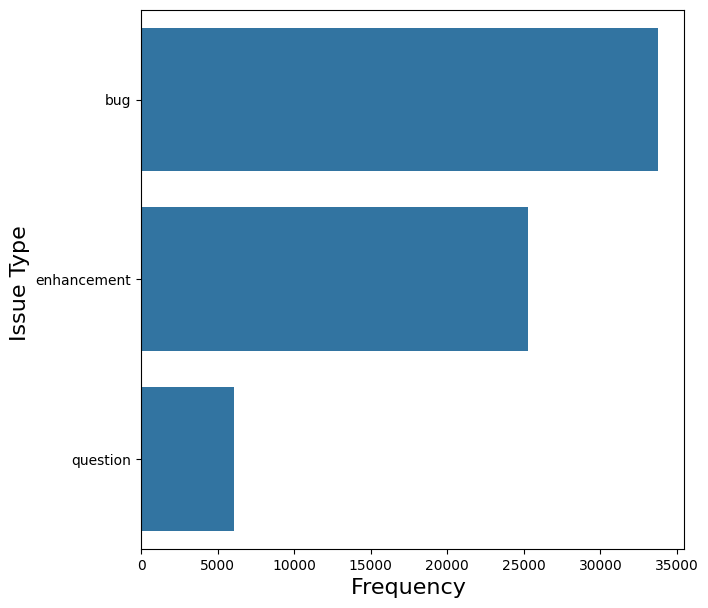

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

sns.barplot(data=issue_label_counts_df,
            x='count',
            y='issue_label',
            dodge=False,
            ax=ax)

plt.ylabel("Issue Type ",fontsize=16)
plt.xlabel("Frequency ",fontsize=16)

# Data Preprocessing


In [9]:
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('wordnet2022')
nltk.download('stopwords')
lemmatizer=WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package wordnet2022 to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet2022.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Removing words like bug, enhancement, and question from the issue title

In [10]:
for index, row in issues_df.iterrows():
  issue_title=row.issue_title.lower()
  if 'bug' in issue_title:
    issues_df.loc[index,'issue_title']=re.sub(r'bug',"",issue_title)
  if 'enhancement' in issue_title:
    issues_df.loc[index,'issue_title']=re.sub(r"enhancement","",issue_title)
  if 'question' in issue_title:
    issues_df.loc[index,'issue_title']=re.sub(r"question","",issue_title)

In [ ]:
#Check if the filtering worked or not
bug,enhancement,question=0,0,0
for index, row in issues_df.iterrows():
  issue_title=row.issue_title.lower()
  if 'bug' in issue_title:
    bug+=1
  if 'enhancement' in issue_title:
    enhancement+=1
  if 'question' in issue_title:
    question+=1

print(f"{bug}, {enhancement}, {question}")

16, 2, 0


# Combining columns issue_title and issue_body

In [11]:
issues = [row.issue_title+' '+row.issue_body for index, row in issues_df.iterrows()]

In [12]:
#first 5 issues
issues[0:5]

['__tileSrcRect is null in Entities.ldtk Sample But Not Nullable According to JSON Schema In the Entities example, we there are some `__tileSrcRect` fields that are null:\r\n\r\nhttps://github.com/deepnight/ldtk/blob/03d51ec1b19275554f0b67b8e56370baca230a44/app/samples/Entities.ldtk#L993-L995\r\n\r\nBut according to the schema that field is required:\r\n\r\nhttps://github.com/deepnight/ldtk/blob/03d51ec1b19275554f0b67b8e56370baca230a44/docs/JSON_SCHEMA.json#L1251-L1254\r\n\r\nMy Rust crate failed to validate the Entities sample because of the difference. It turns out the Rust crate makes a good test-case for the schema. :smile:',
 'Update the blog link in the SEF Site **Describe the bug**\r\nUpdate the blog link in the entire website to the new link `https://sefglobal.medium.com/`\r\nPlease find the blog page access places in the following places\r\n1) Navigation Bar\r\n2) Footer\r\n\r\n**Expected behavior**\r\nThe blog hyperlink should be redirected to the medium SEF Channel.',
 '🐛 Pa

# Noise removal, Normalization, Tokenization, Removing Stop words and Lemmatization

In [ ]:
b=[]
for c in issues[0:2]:
  a = re.sub('[^a-zA-Z?!]', ' ', c)
  # Normalization: making every character lowercase
  a = a.lower()
  # Tokenization: splitting words by space
  a=simple_preprocess(a)
  a = [lemmatizer.lemmatize(word) for word in a if not word in stopwords.words('english')]
  # i = ' '.join(i)
  b.append(a)

print(b)

[['tilesrcrect', 'null', 'entity', 'ldtk', 'sample', 'nullable', 'according', 'json', 'schema', 'entity', 'example', 'tilesrcrect', 'field', 'null', 'http', 'github', 'com', 'deepnight', 'ldtk', 'blob', 'ec', 'baca', 'app', 'sample', 'entity', 'ldtk', 'according', 'schema', 'field', 'required', 'http', 'github', 'com', 'deepnight', 'ldtk', 'blob', 'ec', 'baca', 'doc', 'json', 'schema', 'json', 'rust', 'crate', 'failed', 'validate', 'entity', 'sample', 'difference', 'turn', 'rust', 'crate', 'make', 'good', 'test', 'case', 'schema', 'smile'], ['update', 'blog', 'link', 'sef', 'site', 'describe', 'bug', 'update', 'blog', 'link', 'entire', 'website', 'new', 'link', 'http', 'sefglobal', 'medium', 'com', 'please', 'find', 'blog', 'page', 'access', 'place', 'following', 'place', 'navigation', 'bar', 'footer', 'expected', 'behavior', 'blog', 'hyperlink', 'redirected', 'medium', 'sef', 'channel']]


In [ ]:
#Remove special characters, remove stopwords and lemmatize and store as corpus
corpus = [] #list of list of tokens
for issue in tqdm(issues):
    # Noise Removal: converting every non alphabetical or non english character to blank space
    i = re.sub('[^a-zA-Z?!]', ' ', issue)
    # Normalization: making every character lowercase
    i = i.lower()
    # Tokenization: splitting words by space
    i = i.split()
    # i=simple_preprocess(i)

    # Stop word removal and Lemmatization: applying lemmatization to words which are not stopwords
    i = [lemmatizer.lemmatize(word) for word in i if not word in stopwords.words('english')]
    # i = ' '.join(i)
    corpus.append(i)

100%|██████████| 65141/65141 [20:27<00:00, 53.07it/s]


# Save the corpus

In [ ]:
with open("/content/corpus.bin", "wb") as output:
    pickle.dump(corpus, output)

### Load corpus

In [13]:
corpus= pd.read_pickle(r'/content/corpus.bin')

In [14]:
len(corpus)

65141

In [15]:
corpus[:5]

[['tilesrcrect',
  'null',
  'entity',
  'ldtk',
  'sample',
  'nullable',
  'according',
  'json',
  'schema',
  'entity',
  'example',
  'tilesrcrect',
  'field',
  'null',
  'http',
  'github',
  'com',
  'deepnight',
  'ldtk',
  'blob',
  'ec',
  'b',
  'f',
  'b',
  'b',
  'e',
  'baca',
  'app',
  'sample',
  'entity',
  'ldtk',
  'l',
  'l',
  'according',
  'schema',
  'field',
  'required',
  'http',
  'github',
  'com',
  'deepnight',
  'ldtk',
  'blob',
  'ec',
  'b',
  'f',
  'b',
  'b',
  'e',
  'baca',
  'doc',
  'json',
  'schema',
  'json',
  'l',
  'l',
  'rust',
  'crate',
  'failed',
  'validate',
  'entity',
  'sample',
  'difference',
  'turn',
  'rust',
  'crate',
  'make',
  'good',
  'test',
  'case',
  'schema',
  'smile'],
 ['update',
  'blog',
  'link',
  'sef',
  'site',
  'describe',
  'bug',
  'update',
  'blog',
  'link',
  'entire',
  'website',
  'new',
  'link',
  'http',
  'sefglobal',
  'medium',
  'com',
  'please',
  'find',
  'blog',
  'page',
  '

# Training Word2Vec from scratch


In [ ]:
import multiprocessing
cores = multiprocessing.cpu_count() # Count the number of cores in a computer
cores

2

## Why I seperate the training of the model in 3 steps:
I prefer to separate the training in 3 distinctive steps for clarity and monitoring.
1. `Word2Vec()`:
>In this first step, I set up the parameters of the model one-by-one. <br>I do not supply the parameter `sentences`, and therefore leave the model uninitialized, purposefully.
2. `.build_vocab()`:
>Here it builds the vocabulary from a sequence of sentences and thus initialized the model. <br>With the loggings, I can follow the progress and even more important, the effect of `min_count` and `sample` on the word corpus. I noticed that these two parameters, and in particular `sample`, have a great influence over the performance of a model. Displaying both allows for a more accurate and an easier management of their influence.
3. `.train()`:
>Finally, trains the model.<br>
The loggings here are mainly useful for monitoring, making sure that no threads are executed instantaneously.

## The parameters:

* `min_count` <font color='purple'>=</font> <font color='green'>int</font> - Ignores all words with total absolute frequency lower than this - (2, 100)


* `window` <font color='purple'>=</font> <font color='green'>int</font> - The maximum distance between the current and predicted word within a sentence. E.g. `window` words on the left and `window` words on the left of our target - (2, 10)


* `size` <font color='purple'>=</font> <font color='green'>int</font> - Dimensionality of the feature vectors. - (50, 300)


* `sample` <font color='purple'>=</font> <font color='green'>float</font> - The threshold for configuring which higher-frequency words are randomly downsampled. Highly influencial.  - (0, 1e-5)


* `alpha` <font color='purple'>=</font> <font color='green'>float</font> - The initial learning rate - (0.01, 0.05)


* `min_alpha` <font color='purple'>=</font> <font color='green'>float</font> - Learning rate will linearly drop to `min_alpha` as training progresses. To set it: alpha - (min_alpha * epochs) ~ 0.00


* `negative` <font color='purple'>=</font> <font color='green'>int</font> - If > 0, negative sampling will be used, the int for negative specifies how many "noise words" should be drown. If set to 0, no negative sampling is used. - (5, 20)


* `workers` <font color='purple'>=</font> <font color='green'>int</font> - Use these many worker threads to train the model (=faster training with multicore machines)

In [ ]:
w2v_model = gensim.models.Word2Vec(min_count=5,
                                   window=2,
                                   vector_size=100,
                                   sample=6e-5,
                                   alpha=0.03,
                                   min_alpha=0.0001,
                                   negative=20,
                                   workers=cores-1)

# Building the Vocabulary Table:
Word2Vec requires us to build the vocabulary table (simply digesting all the words and filtering out the unique words, and doing some basic counts on them):



In [ ]:
from time import time
t = time()
w2v_model.build_vocab(corpus, progress_per=5000)
print(f'Time to build vocab: {round((time() - t) / 60, 2)} mins')

Time to build vocab: 0.04 mins


In [ ]:
w2v_model.corpus_count

65141

## Training of the model:
_Parameters of the training:_
* `total_examples` <font color='purple'>=</font> <font color='green'>int</font> - Count of sentences;
* `epochs` <font color='purple'>=</font> <font color='green'>int</font> - Number of iterations (epochs) over the corpus - [10, 20, 30]

In [ ]:
t = time()

w2v_model.train(corpus, total_examples=w2v_model.corpus_count, epochs=15, report_delay=1)

print(f'Time to train the model: {round((time() - t) / 60, 2)} mins')

Time to train the model: 7.42 mins


In [ ]:
#Save the model
w2v_model.save("/content/word2vec.model")

In [16]:
#Load the model
w2v_model = gensim.models.Word2Vec.load("/content/word2vec.model")

In [19]:
# w2v_model.wv.index_to_key

# Check vocabulary size
w2v_model.corpus_count

# w2v_model.epochs

65141

In [20]:
w2v_model.wv['error']

array([-0.3455261 , -0.03122407,  1.1035837 ,  0.1619601 ,  0.02664948,
       -0.37177074, -0.41969603, -0.4645207 ,  0.31654555, -0.03097408,
       -0.4220469 , -0.03817979,  0.1887213 ,  0.7627627 , -0.5224535 ,
       -0.44071314,  0.94281495, -0.2104719 ,  0.18827617, -0.37995613,
        0.31951576,  0.8306074 , -0.13707016, -0.03965835, -0.02026165,
       -0.657913  , -0.5554485 , -0.19121058, -0.07506853,  0.12925684,
        0.69349456,  0.6982977 ,  0.24102022, -0.11127676,  0.8248921 ,
       -0.07455518, -0.15977532, -0.54925925, -0.3703437 , -0.50758064,
       -0.8034951 ,  0.32450628,  0.5057609 ,  0.54981285, -0.6140912 ,
        0.06439002,  0.8875591 , -0.4784516 ,  0.34953633, -1.1681907 ,
       -0.9112794 ,  0.46205854,  0.02899607, -0.7563746 ,  0.1461997 ,
        1.3089843 ,  0.78565097, -0.8253609 , -0.34553248, -0.35670176,
       -0.68227595, -0.47226205, -0.41761202,  0.03842661, -1.0472794 ,
        0.11317421, -0.5788032 , -0.28093305,  0.3192247 ,  1.19

In [21]:
w2v_model.wv['error'].shape

(100,)

In [22]:
w2v_model.wv.similar_by_word('error')

[('message', 0.7242826223373413),
 ('exception', 0.719793438911438),
 ('warning', 0.6755629181861877),
 ('failed', 0.6543905138969421),
 ('failure', 0.6401177048683167),
 ('occured', 0.6342276334762573),
 ('saying', 0.6327155828475952),
 ('occurred', 0.6252583861351013),
 ('notfound', 0.6007234454154968),
 ('following', 0.598601222038269)]

In [23]:
w2v_model.wv.similarity('bug', 'problem')

0.7045886

# Average the vectors of each word in a sentence to a single vector


In [54]:
# To average the vectors of each word in a sentence to a single vector
def avg_word2vec(doc):
    # remove out-of-vocabulary words
    return np.mean([w2v_model.wv[word] for word in doc if word in w2v_model.wv.index_to_key],axis=0)

### Applying AvgerageWord2Vec for the entire sentences


In [ ]:
#this cells take time
word_vectors=[avg_word2vec(word) for word in tqdm(corpus)]

100%|██████████| 65141/65141 [25:20<00:00, 42.84it/s]


In [ ]:
word_vectors = np.asarray(word_vectors, dtype="object")
word_vectors

array([array([-0.18333046,  0.16726948,  0.02720061, -0.0631427 , -0.07379561,
              -0.26797876, -0.09033172,  0.44603997,  0.04888091,  0.34006187,
              -0.44716865,  0.03544439,  0.09758096,  0.2276329 , -0.50322974,
              -0.39373532,  0.27107203,  0.1982036 ,  0.7012738 , -0.5049799 ,
               1.0540345 ,  0.02384563,  0.10874569,  0.05373267, -0.13445652,
              -0.3456267 , -0.39046454, -0.21079385,  0.66989416,  0.24671711,
               0.0194068 ,  0.17093135,  0.39046627, -0.14456789, -0.266404  ,
               0.05930984, -0.2663895 , -0.2229517 , -0.06976324, -0.36205497,
               0.23504733, -0.06886219,  0.05245289,  0.44724286,  0.1855673 ,
               0.28588414,  0.15346624, -0.35469425,  0.53262055,  0.16370454,
               0.3534134 ,  0.11694655,  0.17945981,  0.01919562,  0.49505314,
              -0.13542052,  0.36510804, -0.30950722, -0.5738961 ,  0.03175323,
              -0.20483126, -0.49331123,  0.02119847,

In [24]:
# np.save('/content/word_vectors.npy', word_vectors) # save
word_vectors= np.load('/content/word_vectors.npy',allow_pickle=True) # load

In [25]:
word_vectors.shape

(65141,)

In [26]:
issues_df.shape

(65141, 3)

In [27]:
#vector for the first instance
word_vectors[0]

array([-0.18333046,  0.16726948,  0.02720061, -0.0631427 , -0.07379561,
       -0.26797876, -0.09033172,  0.44603997,  0.04888091,  0.34006187,
       -0.44716865,  0.03544439,  0.09758096,  0.2276329 , -0.50322974,
       -0.39373532,  0.27107203,  0.1982036 ,  0.7012738 , -0.5049799 ,
        1.0540345 ,  0.02384563,  0.10874569,  0.05373267, -0.13445652,
       -0.3456267 , -0.39046454, -0.21079385,  0.66989416,  0.24671711,
        0.0194068 ,  0.17093135,  0.39046627, -0.14456789, -0.266404  ,
        0.05930984, -0.2663895 , -0.2229517 , -0.06976324, -0.36205497,
        0.23504733, -0.06886219,  0.05245289,  0.44724286,  0.1855673 ,
        0.28588414,  0.15346624, -0.35469425,  0.53262055,  0.16370454,
        0.3534134 ,  0.11694655,  0.17945981,  0.01919562,  0.49505314,
       -0.13542052,  0.36510804, -0.30950722, -0.5738961 ,  0.03175323,
       -0.20483126, -0.49331123,  0.02119847, -0.08569888, -0.65012133,
       -0.02822145,  0.09356327, -0.5209771 ,  0.07968642,  0.40

In [ ]:
word_vectors[0].shape

(100,)

In [ ]:
# We have to make each vector as one row as the features for the instance
word_vectors[0].reshape(1,-1).shape

(1, 100)

# Final dependent and independent features

In [28]:
#make the feature space for all the datapoints
vec_list=[]
labels=[]
for index,vec in enumerate(word_vectors):
  #Only consider the vectors with shape 100
  if vec.shape==(100,):
    vec_list.append(vec)
    labels.append(issues_df.iloc[index].issue_label)

In [29]:
# We have to make each vector as one row as the features for the instance
df=pd.DataFrame(vec_list)

In [ ]:
#save the features dataframe
df.to_csv('/content/features.csv', index=False)

In [ ]:
#load the features dataframe
df=pd.read_csv('/content/features.csv')

In [30]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.183330,0.167269,0.027201,-0.063143,-0.073796,-0.267979,-0.090332,0.446040,0.048881,0.340062,...,0.150452,-0.150093,0.112723,-0.552558,0.026408,0.325709,0.126728,0.302140,0.188407,-0.456055
1,0.002913,-0.059158,0.508594,-0.055962,0.285850,-0.653397,0.487314,0.517016,-0.179060,0.561651,...,0.021113,-0.020957,-0.336456,-0.368845,-0.418581,-0.012823,0.379955,-0.382215,-0.292078,-0.264914
2,-0.195058,0.138388,0.594031,0.099938,-0.138529,-0.155181,0.178975,-0.237008,0.152681,0.623585,...,0.292672,0.081860,-0.213956,-0.677415,-0.287318,0.381636,-0.002435,0.037999,-0.095761,-0.637458
3,-0.231252,0.308287,0.255935,-0.386737,-0.176144,-0.329907,0.483221,0.367265,-0.374548,0.708094,...,0.165639,0.055931,-0.466921,-0.330380,0.083792,0.128411,-0.126969,-0.257111,-0.193348,-0.315713
4,-0.071926,0.063458,0.329973,0.009781,0.302093,-0.488608,0.423320,0.300049,-0.313922,0.395144,...,0.124487,0.254092,-0.046508,0.003256,0.045585,0.233456,0.028613,-0.210996,0.187136,-0.141500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64763,-0.132464,-0.063113,0.139023,-0.319167,0.213767,-0.363267,-0.050556,0.006900,-0.113609,0.490595,...,0.149650,-0.229629,-0.506318,-0.000052,-0.159305,-0.117963,-0.216968,0.076669,0.224447,-0.293605
64764,0.048794,-0.017655,0.406595,0.028814,0.246484,-0.564032,0.029332,0.090515,-0.152206,0.349918,...,0.266745,-0.424531,-0.302415,-0.085220,-0.262950,0.028434,-0.048538,-0.090784,0.175757,-0.311093
64765,-0.147724,0.127602,0.653783,-0.043580,0.039674,-0.136485,0.234650,0.284733,-0.129211,0.369778,...,0.681867,-0.301453,-0.232889,0.218444,0.319258,0.105341,-0.101262,-0.007120,0.143955,-0.048626
64766,-0.093205,0.042623,0.300215,0.231523,0.805446,-0.502631,0.224438,-0.027549,-0.156864,0.714957,...,0.209538,-0.474297,0.343995,0.158299,-0.387383,0.001303,-0.247601,-0.028465,0.165932,-0.462195


In [ ]:
df.shape

(64768, 100)

### Getting the frequency of each issue type in the data

In [31]:
freq={}
for issue_label in labels:
  freq[issue_label]=freq.get(issue_label,0)+1

print(f"Bugs: {freq['bug']/len(labels)*100 :.2f} %")
print(f"Enhancements : {freq['enhancement']/len(labels)*100 :.2f} %")
print(f"Questions: {freq['question']/len(labels)*100 :.2f} %")

Bugs: 51.90 %
Enhancements : 38.73 %
Questions: 9.37 %


In [32]:
#Independent features
X=df

In [33]:
#dependent feature
labels=np.array(labels)

#encoding the labels
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()
y = le.fit_transform(labels)

In [34]:
labels

array(['bug', 'bug', 'bug', ..., 'question', 'question', 'question'],
      dtype='<U11')

In [35]:
y
#0: bug, 1:enhancement, 2: question

array([0, 0, 0, ..., 2, 2, 2])

In [36]:
y.shape

(64768,)

### Split dataset into training and testing sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [38]:
X_train.shape, y_train.shape

((51814, 100), (51814,))

In [39]:
X_test.shape, y_test.shape

((12954, 100), (12954,))

# Creating a Random Forest Classifier

In [43]:
classifier=RandomForestClassifier()

In [44]:
#Training the RFclassifier
classifier.fit(X_train,y_train)

RandomForestClassifier()

In [45]:
import joblib
# save
joblib.dump(classifier, "/content/rf_classifier.joblib")

# load
# classifier = joblib.load("/content/rf_classifier.joblib")

['/content/rf_classifier.joblib']

In [46]:
#predictions for the test data
y_pred=classifier.predict(X_test)

In [47]:
y_pred.shape

(12954,)

In [48]:
#predicting just the first test value
pred=classifier.predict(X_test[0:1])
pred

array([0])

In [49]:
#predicting the probability of each label
classifier.predict_proba(X_test[0:1])

array([[0.82, 0.15, 0.03]])

In [50]:
y_test[0]

0

# Model evaluation

In [51]:
# print(accuracy_score(y_true=y_test,y_pred=y_pred))
print(classification_report(y_true=y_test,y_pred=y_pred,target_names=['Bug','Enhancement','Question']))
print(f"Macro f1 score: {f1_score(y_true=y_test,y_pred=y_pred,average='macro'):.2f}")

              precision    recall  f1-score   support

         Bug       0.72      0.83      0.77      6688
 Enhancement       0.69      0.71      0.70      5081
    Question       0.53      0.02      0.03      1185

    accuracy                           0.71     12954
   macro avg       0.65      0.52      0.50     12954
weighted avg       0.69      0.71      0.68     12954

Macro f1 score: 0.50


# Making predictions

In [52]:
def make_prediction (issue):
    i = re.sub('[^a-zA-Z?!]', ' ', issue)
    i = i.lower()
    i = i.split()
    i = [lemmatizer.lemmatize(word) for word in i if not word in stopwords.words('english')]
    i = [' '.join(i)]
    x=[avg_word2vec(word) for word in i]
    x = np.asarray(x, dtype="object")
    # the input to the model should be of the shape (1,100)
    x.reshape(1,-1)

    return classifier.predict_proba(x).tolist()[0]

In [57]:
bug,enhancement,question=make_prediction("please fix the error on line 20")
print(f'Probability of bug: {bug:.2f} \nProbability of enhancement: {enhancement:.2f}\nProbability of question: {question:.2f}')

Probability of bug: 0.57 
Probability of enhancement: 0.32
Probability of question: 0.11
